## Configurazione e import

In [2]:
import warnings
warnings.filterwarnings("ignore")

import time
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.model_selection import (train_test_split, StratifiedKFold,
                                      cross_val_score, cross_val_predict, GridSearchCV)
from sklearn.base import clone
from sklearn.compose import ColumnTransformer
from sklearn.pipeline import Pipeline
from sklearn.impute import SimpleImputer
from sklearn.preprocessing import StandardScaler, OneHotEncoder
from sklearn.discriminant_analysis import LinearDiscriminantAnalysis

from sklearn.linear_model import LogisticRegression
from sklearn.svm import LinearSVC
from sklearn.ensemble import RandomForestClassifier
from xgboost import XGBClassifier

from imblearn.over_sampling import SMOTE
from imblearn.under_sampling import NearMiss

from sklearn.metrics import (classification_report, confusion_matrix, f1_score,
                             precision_score, recall_score, roc_auc_score,
                             average_precision_score, roc_curve, precision_recall_curve,
                             ConfusionMatrixDisplay)

from MetaCost import MetaCost   

sns.set_theme(style="whitegrid")
RANDOM_STATE = 42
np.random.seed(RANDOM_STATE)

In [3]:
DATA_PATH   = "dataset/weatherAUS.csv"  
N_SAMPLE    = None    # righe usate 
N_SAMPLE_MC = 15000     # sottocampione dedicato a MetaCost
CV_FOLDS    = 3

# Matrice dei costi per MetaCost, adattata a RainTomorrow (classe 1 = pioggia, minoritaria).
# C[i, j] = costo di predire i quando la verità è j.
#   C[0,1] = predire "No" quando piove  -> FALSO NEGATIVO (grave: pioggia mancata)
#   C[1,0] = predire "Sì" quando non piove -> falso allarme (lieve)
COST_FN = 5   # costo del falso negativo (pioggia mancata)
COST_FP = 1   # costo del falso positivo (falso allarme)
COST_MATRIX = np.array([[0, COST_FN],
                        [COST_FP, 0]])
print("Matrice dei costi MetaCost:\n", COST_MATRIX)

Matrice dei costi MetaCost:
 [[0 5]
 [1 0]]


## Caricamento e pulizia

In [4]:
# Elimino le righe con target mancante e campiono un sottoinsieme se richiesto
df = pd.read_csv(DATA_PATH, na_values="NA")
df = df.dropna(subset=["RainTomorrow"]).reset_index(drop=True)

if N_SAMPLE is not None and N_SAMPLE < len(df):
    df = df.sample(N_SAMPLE, random_state=RANDOM_STATE).reset_index(drop=True)

# Estraggo il mese dalla data 
df["Date"]  = pd.to_datetime(df["Date"])
df["Month"] = df["Date"].dt.month
# Converto le colonne RainToday e RainTomorrow in binarie
for c in ["RainToday", "RainTomorrow"]:
    df[c] = df[c].map({"No": 0, "Yes": 1})

# Scarto alcune colonne con troppi valori mancanti o poco informative
SPARSE_DROP = ["Sunshine", "Evaporation", "Cloud9am", "Cloud3pm"]
X = df.drop(columns=["RainTomorrow", "Date"] + SPARSE_DROP)
y = df["RainTomorrow"].astype(int)

numeric_cols = X.select_dtypes(include=["number"]).columns.tolist()
numeric_cols = [c for c in numeric_cols if c != "Month"]
categorical_cols = X.select_dtypes(include=["object"]).columns.tolist() + ["Month"]

print(f"Righe usate: {len(df):,}")
print(f"Numeriche ({len(numeric_cols)}): {numeric_cols}")
print(f"Categoriche ({len(categorical_cols)}): {categorical_cols}")

Righe usate: 142,193
Numeriche (13): ['MinTemp', 'MaxTemp', 'Rainfall', 'WindGustSpeed', 'WindSpeed9am', 'WindSpeed3pm', 'Humidity9am', 'Humidity3pm', 'Pressure9am', 'Pressure3pm', 'Temp9am', 'Temp3pm', 'RainToday']
Categoriche (5): ['Location', 'WindGustDir', 'WindDir9am', 'WindDir3pm', 'Month']


## Split train/test e preprocessing

In [5]:
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, stratify=y, random_state=RANDOM_STATE)

preprocessor = ColumnTransformer([
    # Imputazione con la mediana e scaler per le colonne numeriche
    ("num", Pipeline([("imp", SimpleImputer(strategy="median")),
                      ("sc",  StandardScaler())]), numeric_cols),
    # Imputazione con la moda e OneHotEncoder per le colonne categoriche
    ("cat", Pipeline([("imp", SimpleImputer(strategy="most_frequent")),
                      ("oh",  OneHotEncoder(handle_unknown="ignore"))]), categorical_cols),
])
print(f"Train: {X_train.shape} | Test: {X_test.shape}")

Train: (113754, 18) | Test: (28439, 18)


## Problema: target sbilanciato

Train -> No pioggia: 88,252 (77.6%) | Pioggia: 25,502 (22.4%)
Rapporto di sbilanciamento: 3.46 : 1


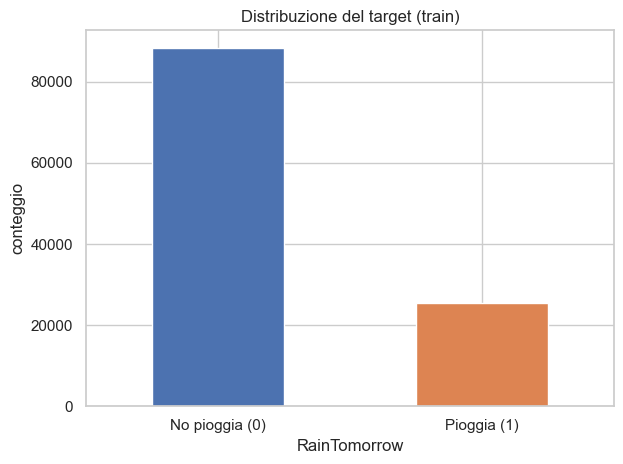

In [6]:
# Calcola la frequenza delle classi nel target di addestramento e le ordina per indice
dist = y_train.value_counts().sort_index()
# Calcola il rapporto tra i casi negativi e quelli positivi 
ratio = dist[0] / dist[1]
print(f"Train -> No pioggia: {dist[0]:,} ({dist[0]/len(y_train):.1%}) | "
      f"Pioggia: {dist[1]:,} ({dist[1]/len(y_train):.1%})")
print(f"Rapporto di sbilanciamento: {ratio:.2f} : 1")

ax = dist.plot(kind="bar", color=["#4C72B0", "#DD8452"])
ax.set_xticklabels(["No pioggia (0)", "Pioggia (1)"], rotation=0)
ax.set_title("Distribuzione del target (train)"); ax.set_ylabel("conteggio")
plt.tight_layout();
plt.show()

## Confronto dei 4 modelli in cross-validation

In [7]:
cv = StratifiedKFold(n_splits=CV_FOLDS, shuffle=True, random_state=RANDOM_STATE)
spw = float(ratio)  # scale_pos_weight per XGBoost

candidates = {
    "Logistic Regression": LogisticRegression(max_iter=2000, class_weight="balanced",
                                               random_state=RANDOM_STATE),
    "Linear SVM":          LinearSVC(class_weight="balanced", random_state=RANDOM_STATE),
    "Random Forest":       RandomForestClassifier(n_estimators=150, n_jobs=-1,
                                                  class_weight="balanced_subsample",
                                                  random_state=RANDOM_STATE),
    "XGBoost":             XGBClassifier(n_estimators=150, learning_rate=0.1, n_jobs=-1,
                                         scale_pos_weight=spw, eval_metric="logloss",
                                         random_state=RANDOM_STATE),
}

cv_results = {}
for name, clf in candidates.items():
    pipe = Pipeline([("pre", preprocessor), ("clf", clf)])
    t = time.time()
    scores = cross_val_score(pipe, X_train, y_train, cv=cv, scoring="f1", n_jobs=-1)
    cv_results[name] = scores.mean()
    print(f"{name:22s} F1 = {scores.mean():.4f} (+/- {scores.std():.4f})   [{time.time()-t:.0f}s]")

best_name = max(cv_results, key=cv_results.get)
print(f"\nMigliore in CV: {best_name}  (F1 = {cv_results[best_name]:.4f})")

Logistic Regression    F1 = 0.6171 (+/- 0.0018)   [7s]
Linear SVM             F1 = 0.6184 (+/- 0.0019)   [5s]
Random Forest          F1 = 0.5906 (+/- 0.0044)   [145s]
XGBoost                F1 = 0.6480 (+/- 0.0036)   [9s]

Migliore in CV: XGBoost  (F1 = 0.6480)


## Studio delle varie tecniche per lo sbilanciamento

In [8]:
# NearMiss e' O(n_maggioritaria x n_minoritaria)) ---
N_STUDY = 20000

X_study, _, y_study, _ = train_test_split(
    X_train, y_train,
    train_size=min(N_STUDY, len(X_train)),
    stratify=y_train, random_state=RANDOM_STATE)

# preprocessing "fuori pipeline" solo per questo studio comparativo (fit su train, transform su val)
Xtr2, Xval, ytr2, yval = train_test_split(
    X_study, y_study, test_size=0.25, stratify=y_study, random_state=RANDOM_STATE)

# Fit delle trasformazioni solo sul sotto-train per evitare data leakage, poi transform sul val
pre_study = clone(preprocessor).fit(Xtr2)
Xtr2_p = pre_study.transform(Xtr2); Xval_p = pre_study.transform(Xval)

# Converte da matrice sparsa a numpy array denso se necessario 
Xtr2_d = Xtr2_p.toarray() if hasattr(Xtr2_p, "toarray") else Xtr2_p
Xval_d = Xval_p.toarray() if hasattr(Xval_p, "toarray") else Xval_p

def evaluate(model, Xv, yv, name):
    pred = model.predict(Xv)
    row = {"strategia": name,
           "F1":        f1_score(yv, pred),
           "precision": precision_score(yv, pred),
           "recall":    recall_score(yv, pred)}
    print(f"{name:26s} F1={row['F1']:.3f}  Precision={row['precision']:.3f}  Recall={row['recall']:.3f}")
    return row

results = []
# 1 baseline (nessuna gestione dello sbilanciamento)
results.append(evaluate(LogisticRegression(max_iter=2000).fit(Xtr2_d, ytr2), Xval_d, yval, "Baseline"))
# 2 class_weight
results.append(evaluate(LogisticRegression(max_iter=2000, class_weight="balanced").fit(Xtr2_d, ytr2),
                        Xval_d, yval, "class_weight"))
# 3 SMOTE
Xs, ys = SMOTE(random_state=RANDOM_STATE).fit_resample(Xtr2_d, ytr2)
results.append(evaluate(LogisticRegression(max_iter=2000).fit(Xs, ys), Xval_d, yval, "SMOTE"))
# 4 NearMiss + SMOTE
Xu, yu = NearMiss(version=2).fit_resample(Xtr2_d, ytr2)
Xus, yus = SMOTE(random_state=RANDOM_STATE).fit_resample(Xu, yu)
results.append(evaluate(LogisticRegression(max_iter=2000).fit(Xus, yus), Xval_d, yval, "NearMiss+SMOTE"))
# 5 LDA + class_weight
lda = LinearDiscriminantAnalysis()
Xtr2_l = lda.fit_transform(Xtr2_d, ytr2); Xval_l = lda.transform(Xval_d)
results.append(evaluate(LogisticRegression(max_iter=2000, class_weight="balanced").fit(Xtr2_l, ytr2),
                        Xval_l, yval, "LDA + class_weight"))

Baseline                   F1=0.590  Precision=0.710  Recall=0.505
class_weight               F1=0.611  Precision=0.514  Recall=0.754
SMOTE                      F1=0.612  Precision=0.516  Recall=0.750
NearMiss+SMOTE             F1=0.509  Precision=0.402  Recall=0.691
LDA + class_weight         F1=0.607  Precision=0.518  Recall=0.732


In [9]:
# 6 MetaCost (su sottocampione)
def run_metacost(Xtr_d, ytr_arr, Xv_d, yv, base_model, C, title, m=8, n_sub=N_SAMPLE_MC):
    n_sub = min(n_sub, len(Xtr_d))
    S = pd.DataFrame(Xtr_d[:n_sub], columns=[f"f{i}" for i in range(Xtr_d.shape[1])])
    S["RainTomorrow"] = np.asarray(ytr_arr)[:n_sub]
    mc = MetaCost(S=S, L=base_model, C=C, m=m, p=True)
    trained = mc.fit("RainTomorrow", 2)
    return evaluate(trained, Xv_d, yv, title)

results.append(run_metacost(Xtr2_d, ytr2.values, Xval_d, yval,
                            LogisticRegression(max_iter=2000), COST_MATRIX, "MetaCost (LR)"))
results.append(run_metacost(Xtr2_l, ytr2.values, Xval_l, yval,
                            LogisticRegression(max_iter=2000), COST_MATRIX, "MetaCost + LDA"))

study = pd.DataFrame(results).set_index("strategia").round(3)
print("\n=== Riepilogo strategie (validation) ===")
study

MetaCost (LR)              F1=0.585  Precision=0.455  Recall=0.820
MetaCost + LDA             F1=0.584  Precision=0.459  Recall=0.803

=== Riepilogo strategie (validation) ===


,F1,precision,recall
strategia,,,
Baseline,0.590,0.710,0.505
class_weight,0.611,0.514,0.754
SMOTE,0.612,0.516,0.750
NearMiss+SMOTE,0.509,0.402,0.691
LDA + class_weight,0.607,0.518,0.732
MetaCost (LR),0.585,0.455,0.820
MetaCost + LDA,0.584,0.459,0.803


## Ottimizzazione degli iperparametri del modello scelto con GridSearchCV

In [10]:
param_grids = {
    "Logistic Regression": {"clf__C": [0.1, 1.0, 3.0]},
    "Linear SVM":          {"clf__C": [0.1, 1.0, 3.0]},
    "Random Forest":       {"clf__max_depth": [None, 20], "clf__min_samples_leaf": [1, 5]},
    "XGBoost":             {"clf__max_depth": [4, 6], "clf__learning_rate": [0.05, 0.1]},
}
best_estimator_base = candidates[best_name]
grid_pipe = Pipeline([("pre", preprocessor), ("clf", best_estimator_base)])

gs = GridSearchCV(grid_pipe, param_grids[best_name], scoring="f1",
                  cv=StratifiedKFold(3, shuffle=True, random_state=RANDOM_STATE), n_jobs=1)
gs.fit(X_train, y_train)
print(f"Migliori parametri: {gs.best_params_}")
print(f"F1 (CV) ottimizzato: {gs.best_score_:.4f}")
best_model = gs.best_estimator_

Migliori parametri: {'clf__learning_rate': 0.1, 'clf__max_depth': 6}
F1 (CV) ottimizzato: 0.6480


## Calibrazione della soglia di decisione

Soglia ottimale (max F1 OOF): 0.590  ->  F1 = 0.6581


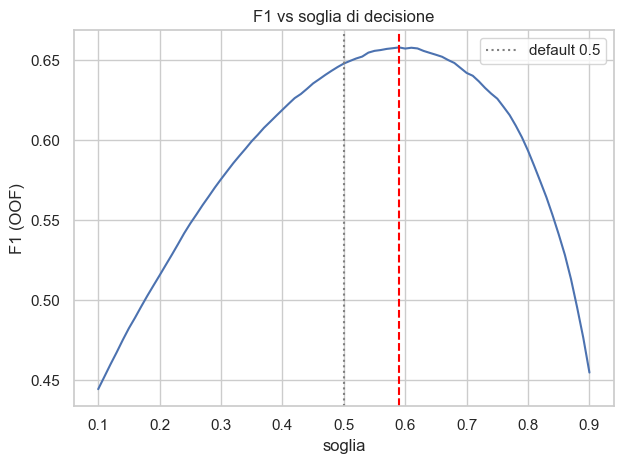

In [11]:
if hasattr(best_model.named_steps["clf"], "n_jobs"):
    best_model.named_steps["clf"].set_params(n_jobs=-1)
    
if hasattr(best_model.named_steps["clf"], "predict_proba"):
    # Calcola le probabilità "Out-Of-Fold" (OOF) sul dataset di training tramite Cross-Validation
    oof = cross_val_predict(best_model, X_train, y_train, cv=cv,
    # [:, 1] estrae solo la probabilità relativa alla classe positiva (Pioggia / 1)
                            method="predict_proba", n_jobs=1)[:, 1]
else:  
    # Estrae i punteggi di decisione grezzi (distanza dall'iperpiano)
    dec = cross_val_predict(best_model, X_train, y_train, cv=cv,
                            method="decision_function", n_jobs=1)
    # Normalizza i punteggi nell'intervallo [0, 1] per simulare una probabilità
    oof = (dec - dec.min()) / (dec.max() - dec.min())

# Definisce una griglia di 81 possibili soglie comprese tra 0.1 e 0.9 (a passi di 0.01)
thresholds = np.linspace(0.1, 0.9, 81)
# Per ciascuna soglia, converte le probabilità OOF in predizioni binarie e calcola l'F1-score corrispondente
f1s = [f1_score(y_train, (oof >= t).astype(int)) for t in thresholds]
# Individua l'indice della soglia che ha ottenuto l'F1-score più alto
best_t = thresholds[int(np.argmax(f1s))]
print(f"Soglia ottimale (max F1 OOF): {best_t:.3f}  ->  F1 = {max(f1s):.4f}")

plt.plot(thresholds, f1s); plt.axvline(best_t, ls="--", color="red")
plt.axvline(0.5, ls=":", color="gray", label="default 0.5")
plt.xlabel("soglia"); plt.ylabel("F1 (OOF)"); plt.title("F1 vs soglia di decisione")
plt.legend(); plt.tight_layout(); plt.show()

## Valutazione finale sul test set

In [12]:
# Riaddestra l'intera pipeline su TUTTO il dataset di train con i parametri ottimali trovati tramite GridSearch
best_model.fit(X_train, y_train)

if hasattr(best_model.named_steps["clf"], "predict_proba"):
    proba_test = best_model.predict_proba(X_test)[:, 1]
else:
    dec = best_model.decision_function(X_test)
    proba_test = (dec - dec.min()) / (dec.max() - dec.min())

y_pred = (proba_test >= best_t).astype(int)

print(f"=== {best_name} + soglia {best_t:.3f} — TEST SET ===\n")
print(classification_report(y_test, y_pred, target_names=["No pioggia", "Pioggia"]))
print(f"ROC-AUC: {roc_auc_score(y_test, proba_test):.4f}")
print(f"PR-AUC : {average_precision_score(y_test, proba_test):.4f}")

=== XGBoost + soglia 0.590 — TEST SET ===

              precision    recall  f1-score   support

  No pioggia       0.91      0.88      0.90     22064
     Pioggia       0.63      0.70      0.66      6375

    accuracy                           0.84     28439
   macro avg       0.77      0.79      0.78     28439
weighted avg       0.85      0.84      0.84     28439

ROC-AUC: 0.8868
PR-AUC : 0.7415


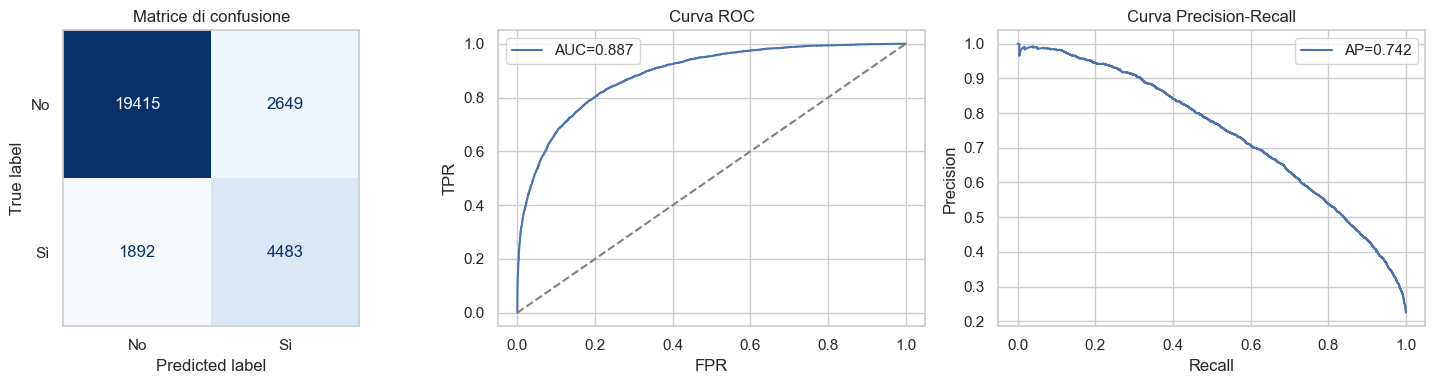

In [14]:
fig, ax = plt.subplots(1, 3, figsize=(15, 4))

ConfusionMatrixDisplay(confusion_matrix(y_test, y_pred),
                       display_labels=["No", "Sì"]).plot(ax=ax[0], colorbar=False, cmap="Blues")
ax[0].grid(False)                      
ax[0].set_title("Matrice di confusione")

fpr, tpr, _ = roc_curve(y_test, proba_test)
ax[1].plot(fpr, tpr, label=f"AUC={roc_auc_score(y_test, proba_test):.3f}")
ax[1].plot([0, 1], [0, 1], "--", color="gray")
ax[1].set_xlabel("FPR"); ax[1].set_ylabel("TPR"); ax[1].set_title("Curva ROC"); ax[1].legend()

prec, rec, _ = precision_recall_curve(y_test, proba_test)
ax[2].plot(rec, prec, label=f"AP={average_precision_score(y_test, proba_test):.3f}")
ax[2].set_xlabel("Recall"); ax[2].set_ylabel("Precision")
ax[2].set_title("Curva Precision-Recall"); ax[2].legend()

plt.tight_layout()
plt.show()

## Importanza delle feature

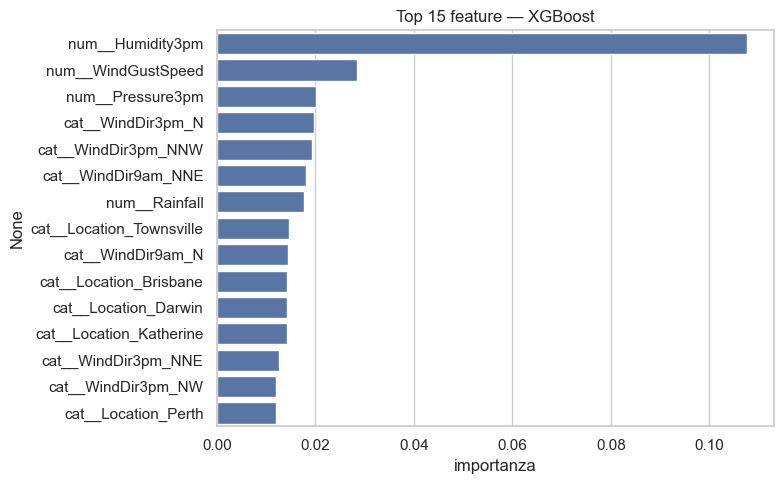

,importanza
num__Humidity3pm,0.1077
num__WindGustSpeed,0.0285
num__Pressure3pm,0.0201
cat__WindDir3pm_N,0.0196
cat__WindDir3pm_NNW,0.0194
cat__WindDir9am_NNE,0.0181
num__Rainfall,0.0177
cat__Location_Townsville,0.0146
cat__WindDir9am_N,0.0145
cat__Location_Brisbane,0.0143


In [15]:
feat_names = best_model.named_steps["pre"].get_feature_names_out()
clf = best_model.named_steps["clf"]

# Estrae i punteggi di importanza a seconda del tipo di modello usato
if hasattr(clf, "feature_importances_"):
    # Modelli ad albero: importanza nativa delle feature
    imp = clf.feature_importances_
elif hasattr(clf, "coef_"):
    # Modelli lineari: prende il valore assoluto dei coefficienti come misura di importanza
    imp = np.abs(clf.coef_).ravel()
else:
    # Modelli senza attributi d'importanza diretti (SVM lineare)
    imp = None

if imp is not None:
    top = (pd.Series(imp, index=feat_names).sort_values(ascending=False).head(15))
    plt.figure(figsize=(8, 5))
    sns.barplot(x=top.values, y=top.index, color="#4C72B0")
    plt.title(f"Top 15 feature — {best_name}"); plt.xlabel("importanza")
    plt.tight_layout(); plt.show()
    display(top.round(4).to_frame("importanza"))
else:
    print("Il modello scelto non espone importanze dirette.")

## Inferenza su giorni concreti

In [17]:
sample_idx = X_test.sample(8, random_state=RANDOM_STATE).index
demo = X_test.loc[sample_idx, ["Location", "Humidity3pm", "Pressure3pm", "RainToday"]].copy()
demo["P(pioggia)"]   = proba_test[[X_test.index.get_loc(i) for i in sample_idx]].round(3)
demo["Previsione"]   = np.where(demo["P(pioggia)"] >= best_t, "Pioggia", "No")
demo["Reale"]        = np.where(y_test.loc[sample_idx] == 1, "Pioggia", "No")
demo

,Location,Humidity3pm,Pressure3pm,RainToday,P(pioggia),Previsione,Reale
38553,WaggaWagga,59.0,1028.5,0.0,0.043,No,No
130470,Launceston,60.0,1008.1,1.0,0.868,Pioggia,No
74271,Portland,93.0,1015.7,0.0,0.930,Pioggia,Pioggia
131982,Launceston,56.0,NaN,0.0,0.250,No,No
84246,Brisbane,51.0,1023.5,0.0,0.189,No,No
12846,Moree,18.0,1011.8,0.0,0.028,No,No
117836,Perth,49.0,1021.7,1.0,0.123,No,No
7160,Cobar,43.0,1023.6,0.0,0.054,No,No
